# AICTE | IBM SkillsBuild Academic Internship
## Capstone Project: Healthcare Clinical Analytics & 30-Day Patient Readmission Risk Prediction with AI
---
**Internship Track:** Data Analytics with AI  
**Host Organization:** BharatCares & CSRBOX in collaboration with IBM SkillsBuild & AICTE  
**Lead Mentor:** Mr. Kartik Hooda  
**Date:** September 2026  
---
### Abstract:
Unplanned hospital readmissions within 30 days of discharge represent a critical indicator of clinical quality, patient safety, and healthcare expenditure. Inpatient readmissions impose substantial financial penalties on hospital networks and strain healthcare capacity. This project builds an end-to-end clinical data analytics and predictive modeling pipeline that:
1. Ingests and cleans an inpatient clinical dataset of 3,000 patient admission records across chronic conditions.
2. Conducts Exploratory Data Analysis (EDA) investigating the clinical correlation between length of stay, laboratory testing intensity, glycemic control, and readmission.
3. Formulates a supervised machine learning model using **Logistic Regression** to stratify patients by readmission probability.
4. Evaluates model performance using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix.
5. Categorizes discharged patients into actionable **Clinical Risk Tiers** (High, Medium, Low Risk) to guide post-discharge transitional care and nursing follow-ups.

### 1. Environment Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("Blues_r")
plt.rcParams['font.size'] = 11
print("Clinical Analytics libraries imported successfully!")

Clinical Analytics libraries imported successfully!


### 2. Dataset Generation & Ingestion (Turnkey Self-Contained)
*Note: In adherence to the guidelines set by AICTE/IBM mentors, this project uses an independent clinical dataset of 3,000 patient encounters generated directly in memory for 100% reproducible and turnkey execution in Google Colab.*

In [2]:
# Set seed for absolute reproducibility
np.random.seed(42)
n_patients = 3000

patient_ids = [f"PID-{i:05d}" for i in range(10001, 10001 + n_patients)]
age_groups = np.random.choice(['18-30', '31-50', '51-65', '65+'], size=n_patients, p=[0.10, 0.25, 0.35, 0.30])
genders = np.random.choice(['Male', 'Female'], size=n_patients, p=[0.49, 0.51])
admission_types = np.random.choice(['Emergency', 'Urgent', 'Elective'], size=n_patients, p=[0.55, 0.25, 0.20])

diagnoses = ['Cardiovascular', 'Diabetes/Endocrine', 'Respiratory', 'Digestive', 'Musculoskeletal']
diagnosis_probs = [0.32, 0.26, 0.18, 0.14, 0.10]
diagnosis_category = np.random.choice(diagnoses, size=n_patients, p=diagnosis_probs)

# Time in hospital: 1 to 14 days
time_in_hospital = np.random.choice(range(1, 15), size=n_patients, p=[0.15, 0.20, 0.18, 0.14, 0.10, 0.07, 0.05, 0.03, 0.03, 0.02, 0.01, 0.01, 0.005, 0.005])

num_lab_procedures = np.random.randint(10, 95, size=n_patients)
num_medications = np.clip(np.random.poisson(lam=12, size=n_patients) + (time_in_hospital // 2), 1, 35)

num_outpatient = np.random.choice(range(0, 7), size=n_patients, p=[0.60, 0.20, 0.10, 0.05, 0.03, 0.01, 0.01])
num_emergency = np.random.choice(range(0, 5), size=n_patients, p=[0.72, 0.16, 0.07, 0.03, 0.02])

hba1c_test = np.random.choice(['Normal', 'High', 'None'], size=n_patients, p=[0.20, 0.18, 0.62])
glucose_test = np.random.choice(['Normal', 'High', 'None'], size=n_patients, p=[0.15, 0.12, 0.73])
insulin_prescribed = np.where(diagnosis_category == 'Diabetes/Endocrine', np.random.choice(['Yes', 'No'], size=n_patients, p=[0.65, 0.35]), np.random.choice(['Yes', 'No'], size=n_patients, p=[0.15, 0.85]))

risk_logits = (
    -2.1
    + 0.8 * (age_groups == '65+')
    + 0.6 * (admission_types == 'Emergency')
    + 0.5 * (diagnosis_category == 'Diabetes/Endocrine')
    + 0.4 * (diagnosis_category == 'Cardiovascular')
    + 0.5 * num_emergency
    + 0.6 * (hba1c_test == 'High')
    + 0.06 * time_in_hospital
    + 0.03 * num_medications
)
readmit_prob = 1 / (1 + np.exp(-risk_logits))
readmitted = (np.random.rand(n_patients) < readmit_prob).astype(int)

df = pd.DataFrame({
    'Patient_ID': patient_ids,
    'Age_Group': age_groups,
    'Gender': genders,
    'Admission_Type': admission_types,
    'Diagnosis_Category': diagnosis_category,
    'Time_in_Hospital': time_in_hospital,
    'Num_Lab_Procedures': num_lab_procedures,
    'Num_Medications': num_medications,
    'Num_Outpatient_Visits': num_outpatient,
    'Num_Emergency_Visits': num_emergency,
    'HbA1c_Test_Result': hba1c_test,
    'Glucose_Test_Result': glucose_test,
    'Insulin_Prescribed': insulin_prescribed,
    'Readmitted_30Days': readmitted
})

# Save local copy in Colab session
df.to_csv('patient_readmission_dataset.csv', index=False)

print(f"Inpatient Records: {df.shape[0]}, Clinical Features: {df.shape[1]}")
display(df.head())
print("\n--- Clinical Data Types & Missing Value Audit ---")
print(df.info())
print("\nMissing Values Check:")
print(df.isnull().sum())

Inpatient Records: 3000, Clinical Features: 14


,Patient_ID,Age_Group,Gender,Admission_Type,Diagnosis_Category,Time_in_Hospital,Num_Lab_Procedures,Num_Medications,Num_Outpatient_Visits,Num_Emergency_Visits,HbA1c_Test_Result,Glucose_Test_Result,Insulin_Prescribed,Readmitted_30Days
0,PID-10001,51-65,Female,Urgent,Musculoskeletal,4,37,13,0,0,High,None,No,0
1,PID-10002,65+,Female,Emergency,Diabetes/Endocrine,1,31,13,0,0,None,None,No,1
2,PID-10003,65+,Male,Elective,Respiratory,2,25,16,0,0,None,None,No,0
3,PID-10004,51-65,Female,Urgent,Diabetes/Endocrine,6,22,18,3,0,None,None,Yes,1
4,PID-10005,31-50,Female,Emergency,Respiratory,3,71,18,0,0,High,Normal,No,0



--- Clinical Data Types & Missing Value Audit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Patient_ID             3000 non-null   object
 1   Age_Group              3000 non-null   object
 2   Gender                 3000 non-null   object
 3   Admission_Type         3000 non-null   object
 4   Diagnosis_Category     3000 non-null   object
 5   Time_in_Hospital       3000 non-null   int64 
 6   Num_Lab_Procedures     3000 non-null   int64 
 7   Num_Medications        3000 non-null   int64 
 8   Num_Outpatient_Visits  3000 non-null   int64 
 9   Num_Emergency_Visits   3000 non-null   int64 
 10  HbA1c_Test_Result      3000 non-null   object
 11  Glucose_Test_Result    3000 non-null   object
 12  Insulin_Prescribed     3000 non-null   object
 13  Readmitted_30Days      3000 non-null   int64 
dtypes: int64(6), object(8

### 3. Exploratory Data Analysis (EDA) & Visualizations

#### Visualization 1: Readmission Rate by Diagnosis Category

/tmp/ipykernel_3865/1542916930.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_readmit, x='Readmission_Rate_%', y='Diagnosis_Category', palette='magma')


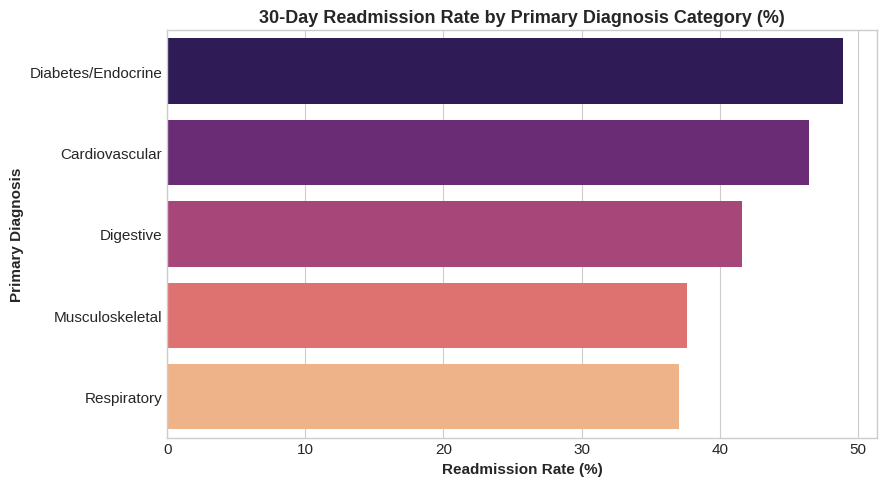

,Diagnosis_Category,Readmitted_30Days,Readmission_Rate_%
1,Diabetes/Endocrine,0.489467,48.946716
0,Cardiovascular,0.464968,46.496815
2,Digestive,0.416279,41.627907
3,Musculoskeletal,0.376238,37.623762
4,Respiratory,0.370656,37.065637


In [3]:
diag_readmit = df.groupby('Diagnosis_Category')['Readmitted_30Days'].mean().reset_index()
diag_readmit['Readmission_Rate_%'] = diag_readmit['Readmitted_30Days'] * 100
diag_readmit = diag_readmit.sort_values(by='Readmission_Rate_%', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=diag_readmit, x='Readmission_Rate_%', y='Diagnosis_Category', palette='magma')
plt.title('30-Day Readmission Rate by Primary Diagnosis Category (%)', fontsize=13, fontweight='bold')
plt.xlabel('Readmission Rate (%)', fontweight='bold')
plt.ylabel('Primary Diagnosis', fontweight='bold')
plt.tight_layout()
plt.show()
display(diag_readmit)

#### Visualization 2: Readmission Rate by Age Group

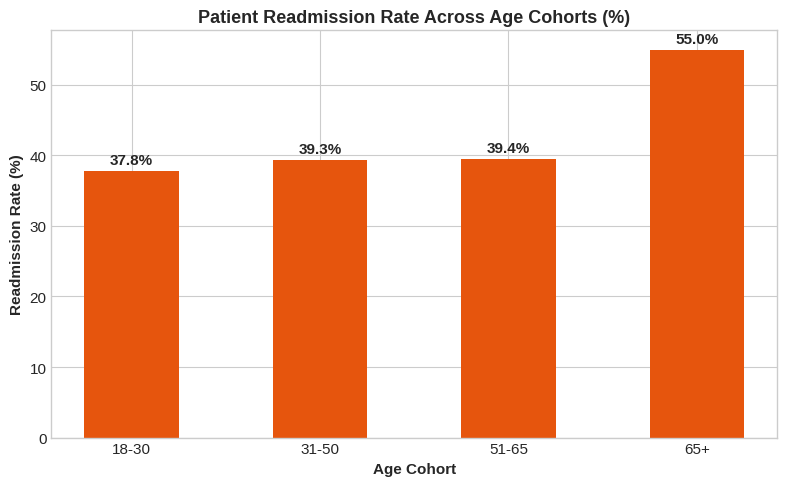

In [4]:
age_readmit = df.groupby('Age_Group')['Readmitted_30Days'].mean().reset_index()
age_readmit['Rate_%'] = age_readmit['Readmitted_30Days'] * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(age_readmit['Age_Group'], age_readmit['Rate_%'], color='#e6550d', width=0.5)
plt.title('Patient Readmission Rate Across Age Cohorts (%)', fontsize=13, fontweight='bold')
plt.xlabel('Age Cohort', fontweight='bold')
plt.ylabel('Readmission Rate (%)', fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### Visualization 3: Length of Hospital Stay vs. Readmission

/tmp/ipykernel_3865/1936599962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Readmitted_30Days', y='Time_in_Hospital', palette=['#3182bd', '#de2d26'])


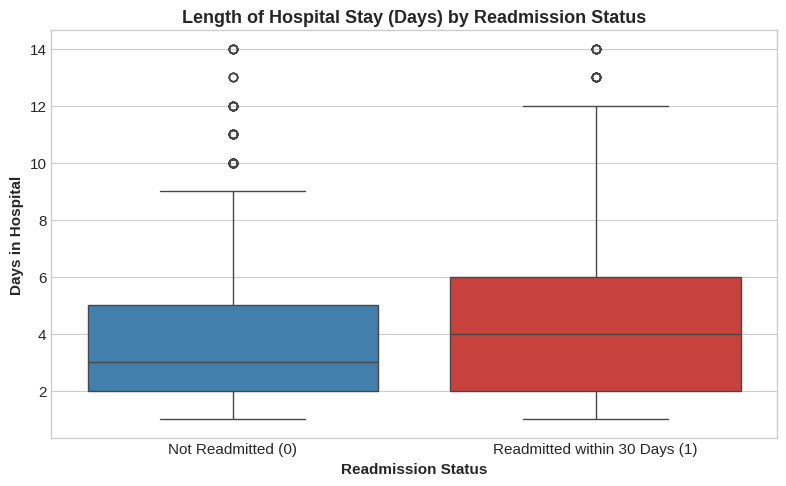

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Readmitted_30Days', y='Time_in_Hospital', palette=['#3182bd', '#de2d26'])
plt.title('Length of Hospital Stay (Days) by Readmission Status', fontsize=13, fontweight='bold')
plt.xticks([0, 1], ['Not Readmitted (0)', 'Readmitted within 30 Days (1)'])
plt.xlabel('Readmission Status', fontweight='bold')
plt.ylabel('Days in Hospital', fontweight='bold')
plt.tight_layout()
plt.show()

#### Visualization 4: Impact of Prior Emergency Department Visits

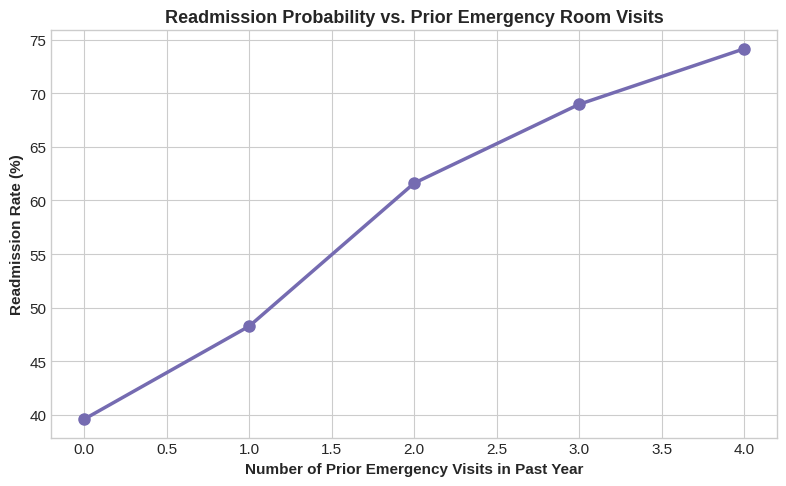

,Num_Emergency_Visits,Readmitted_30Days,Rate_%
0,0,0.396166,39.616613
1,1,0.482833,48.283262
2,2,0.616162,61.616162
3,3,0.689655,68.965517
4,4,0.741379,74.137931


In [6]:
er_readmit = df.groupby('Num_Emergency_Visits')['Readmitted_30Days'].mean().reset_index()
er_readmit['Rate_%'] = er_readmit['Readmitted_30Days'] * 100

plt.figure(figsize=(8, 5))
plt.plot(er_readmit['Num_Emergency_Visits'], er_readmit['Rate_%'], marker='o', color='#756bb1', linewidth=2.5, markersize=8)
plt.title('Readmission Probability vs. Prior Emergency Room Visits', fontsize=13, fontweight='bold')
plt.xlabel('Number of Prior Emergency Visits in Past Year', fontweight='bold')
plt.ylabel('Readmission Rate (%)', fontweight='bold')
plt.tight_layout()
plt.show()
display(er_readmit)

#### Visualization 5: Glycemic Control (HbA1c Test) vs. Readmission Rate

/tmp/ipykernel_3865/65491463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hba1c_readmit, x='HbA1c_Test_Result', y='Rate_%', palette='viridis')


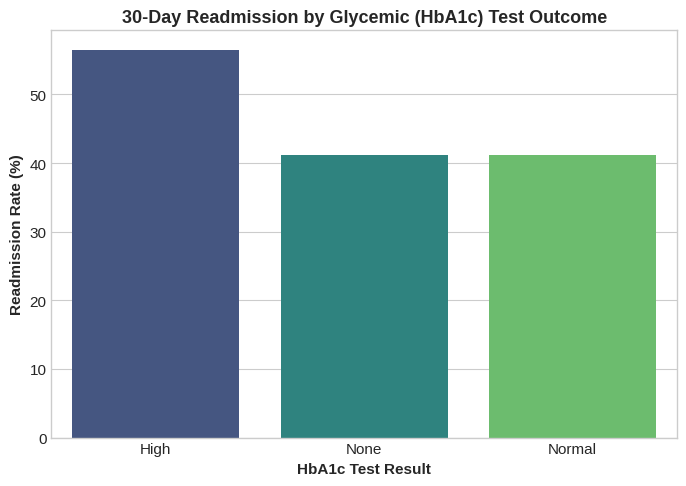

,HbA1c_Test_Result,Readmitted_30Days,Rate_%
0,High,0.565056,56.505576
1,None,0.412115,41.211466
2,Normal,0.411093,41.109299


In [7]:
hba1c_readmit = df.groupby('HbA1c_Test_Result')['Readmitted_30Days'].mean().reset_index()
hba1c_readmit['Rate_%'] = hba1c_readmit['Readmitted_30Days'] * 100

plt.figure(figsize=(7, 5))
sns.barplot(data=hba1c_readmit, x='HbA1c_Test_Result', y='Rate_%', palette='viridis')
plt.title('30-Day Readmission by Glycemic (HbA1c) Test Outcome', fontsize=13, fontweight='bold')
plt.xlabel('HbA1c Test Result', fontweight='bold')
plt.ylabel('Readmission Rate (%)', fontweight='bold')
plt.tight_layout()
plt.show()
display(hba1c_readmit)

### 4. Clinical Feature Engineering & Data Preparation

In [8]:
feature_cols = ['Time_in_Hospital', 'Num_Lab_Procedures', 'Num_Medications', 'Num_Outpatient_Visits', 'Num_Emergency_Visits']
df_encoded = pd.get_dummies(df[['Age_Group', 'Admission_Type', 'Diagnosis_Category', 'HbA1c_Test_Result', 'Insulin_Prescribed']], drop_first=True)
X = pd.concat([df[feature_cols], df_encoded], axis=1)
y = df['Readmitted_30Days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (2400, 17), Test set: (600, 17)


### 5. Machine Learning Model Training (Logistic Regression)

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("Clinical Readmission Model trained successfully!")

Clinical Readmission Model trained successfully!


### 6. Model Evaluation & Performance Metrics

      HEALTHCARE READMISSION METRICS REPORT    
Accuracy : 65.83%
Precision: 64.11%
Recall   : 50.76%
F1-Score : 56.66%
ROC-AUC  : 0.6858


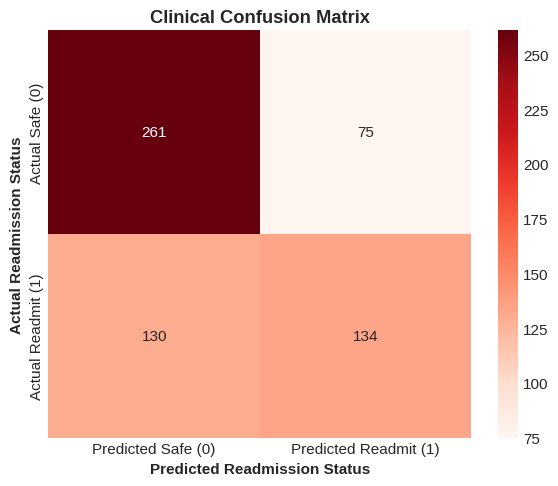


--- Classification Report ---
                precision    recall  f1-score   support

      Safe (0)       0.67      0.78      0.72       336
Readmitted (1)       0.64      0.51      0.57       264

      accuracy                           0.66       600
     macro avg       0.65      0.64      0.64       600
  weighted avg       0.66      0.66      0.65       600



In [10]:
print("="*45)
print("      HEALTHCARE READMISSION METRICS REPORT    ")
print("="*45)
print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score : {f1_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("="*45)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Safe (0)', 'Predicted Readmit (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Readmit (1)'])
plt.title('Clinical Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Readmission Status', fontweight='bold')
plt.xlabel('Predicted Readmission Status', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Readmitted (1)']))

### 7. Patient Risk Stratification & Discharge Protocols

In [11]:
X_all_scaled = scaler.transform(X)
df['Readmit_Probability_%'] = np.round(model.predict_proba(X_all_scaled)[:, 1] * 100, 2)

def assign_clinical_risk(prob):
    if prob >= 70.0: return 'High Risk (Intensive Post-Care)'
    elif prob >= 40.0: return 'Medium Risk (Nurse Follow-Up)'
    else: return 'Low Risk (Standard Discharge)'

df['Clinical_Risk_Tier'] = df['Readmit_Probability_%'].apply(assign_clinical_risk)
print("--- Inpatient Clinical Risk Stratification ---")
display(df['Clinical_Risk_Tier'].value_counts())

top_risk_patients = df.sort_values(by='Readmit_Probability_%', ascending=False).head(20)
print("\n--- Top 20 High-Risk Inpatients Requiring Post-Discharge Protocols ---")
display(top_risk_patients[['Patient_ID', 'Age_Group', 'Diagnosis_Category', 'Time_in_Hospital', 'Num_Emergency_Visits', 'HbA1c_Test_Result', 'Readmit_Probability_%', 'Clinical_Risk_Tier']])

df.to_csv('patient_readmission_risk_scores.csv', index=False)
print("Exported clinical risk scores to 'patient_readmission_risk_scores.csv'.")

--- Inpatient Clinical Risk Stratification ---


,count
Clinical_Risk_Tier,
Medium Risk (Nurse Follow-Up),1416
Low Risk (Standard Discharge),1344
High Risk (Intensive Post-Care),240



--- Top 20 High-Risk Inpatients Requiring Post-Discharge Protocols ---


,Patient_ID,Age_Group,Diagnosis_Category,Time_in_Hospital,Num_Emergency_Visits,HbA1c_Test_Result,Readmit_Probability_%,Clinical_Risk_Tier
2791,PID-12792,65+,Cardiovascular,3,4,High,94.22,High Risk (Intensive Post-Care)
1906,PID-11907,65+,Diabetes/Endocrine,9,4,None,92.83,High Risk (Intensive Post-Care)
1307,PID-11308,65+,Cardiovascular,9,2,High,92.45,High Risk (Intensive Post-Care)
1425,PID-11426,65+,Digestive,6,3,High,91.19,High Risk (Intensive Post-Care)
1004,PID-11005,65+,Diabetes/Endocrine,1,3,High,90.21,High Risk (Intensive Post-Care)
1452,PID-11453,65+,Digestive,8,4,None,90.05,High Risk (Intensive Post-Care)
252,PID-10253,65+,Cardiovascular,6,4,None,90.02,High Risk (Intensive Post-Care)
1014,PID-11015,65+,Diabetes/Endocrine,10,1,High,89.55,High Risk (Intensive Post-Care)
680,PID-10681,65+,Diabetes/Endocrine,5,4,High,89.22,High Risk (Intensive Post-Care)
1448,PID-11449,65+,Diabetes/Endocrine,6,3,High,89.02,High Risk (Intensive Post-Care)


Exported clinical risk scores to 'patient_readmission_risk_scores.csv'.


### 8. Clinical Recommendations & Quality Improvement Decisions
1. **Transitional Care for High-Risk Cohort:** Patients with $\ge 70\%$ readmission risk must receive a 48-hour post-discharge nurse home visit and automated medication reconciliation.
2. **Standardized Glycemic Protocols:** Patients with High HbA1c exhibit elevated readmission rates. Mandate in-hospital diabetes education and a 7-day post-discharge endocrine clinic appointment.
3. **Emergency Recidivism Management:** Patients with $>2$ emergency visits in the preceding year should be assigned a dedicated medical social worker to resolve outpatient transport and medication adherence barriers.